In [1]:
from torch.utils.data import DataLoader
from data_loader import GripperDataset, plot_images, compute_mean_images, load_images
import cv2
import numpy as np
import os

Create dataset and load data

In [ ]:
experiment = "data_collection_clean_env"
sessions = ["1","2"]

dataset = GripperDataset(experiment=experiment, sessions=sessions)
# dataset = GripperDataset(abs_path=path, sessions=sessions)

dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

Loading data session 1
Loading data session 2


Number of samples in the dataset:  4767
Number of batches in the dataloader:  477
Shape bottom image:  [640, 480, 3]
Shape top image:  [720, 1280, 3]
Shape state array:  [9]


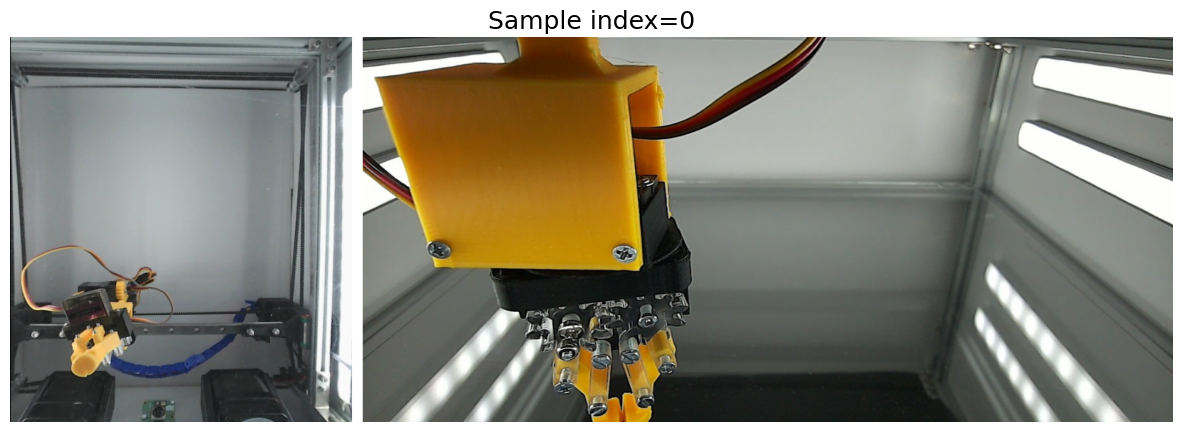

In [3]:
print("Number of samples in the dataset: ", dataset.__len__())
print("Number of batches in the dataloader: ", len(dataloader))
index = 0
bottom_img, top_img, state = dataset[index]

print("Shape bottom image: ", [*bottom_img.shape])
print("Shape top image: ", [*top_img.shape])
print("Shape state array: ", [*state.shape])

plot_images(bottom_img, top_img, title=f"Sample index={index}")

### Mean image
The average of a lot of images is an image of the clean environment, since that is the only static thing while the robot moves. However such average might be biased.

Calculating mean images


100%|██████████| 477/477 [01:56<00:00,  4.09it/s]


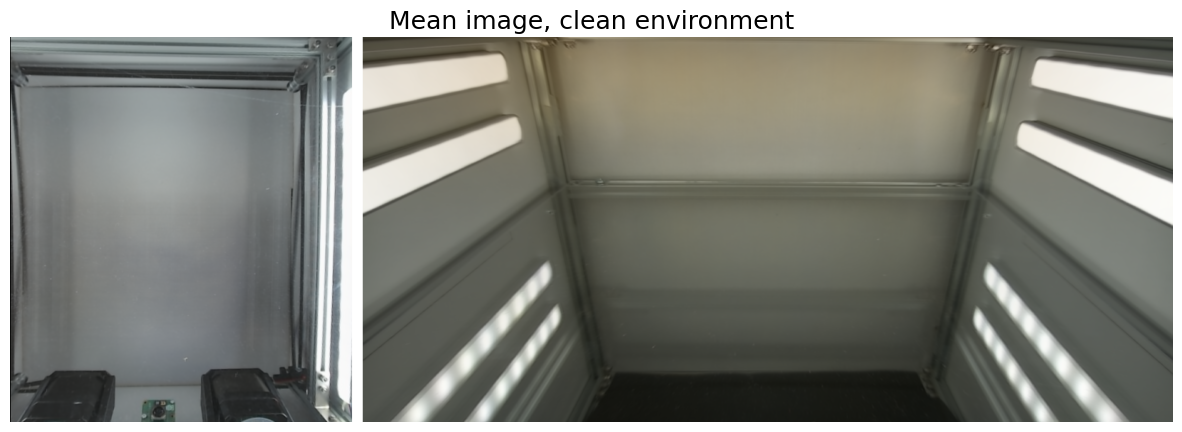

In [ ]:
name = "_mean_Experiment_" + experiment + "_Sessions_" + "_".join(sessions)
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

Remove background, robot mask extraction, by subtracting the clean environment image. 

Then apply threshold to get the mask.

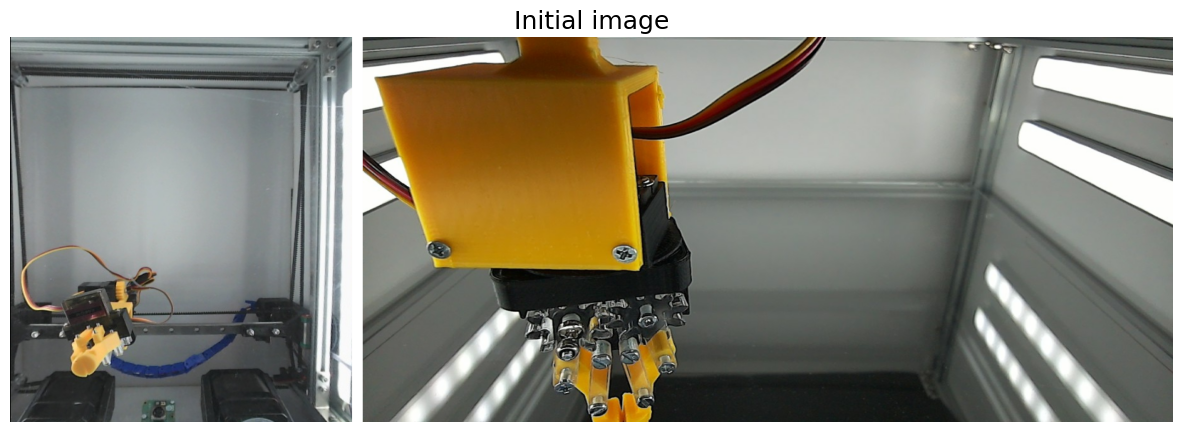

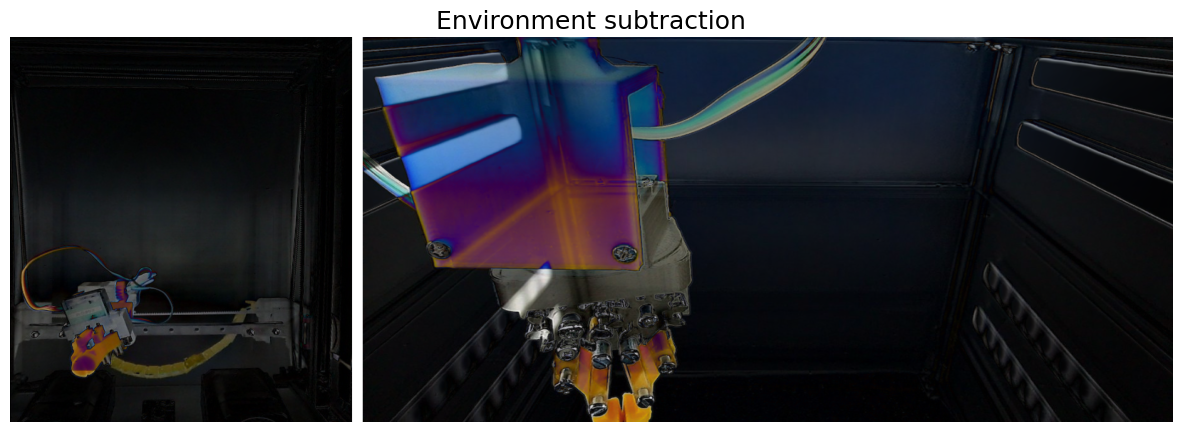

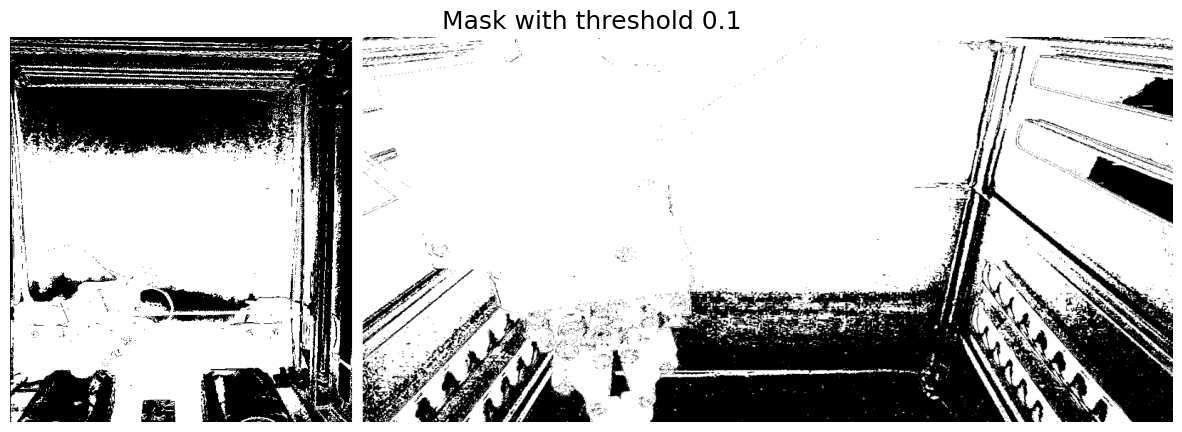

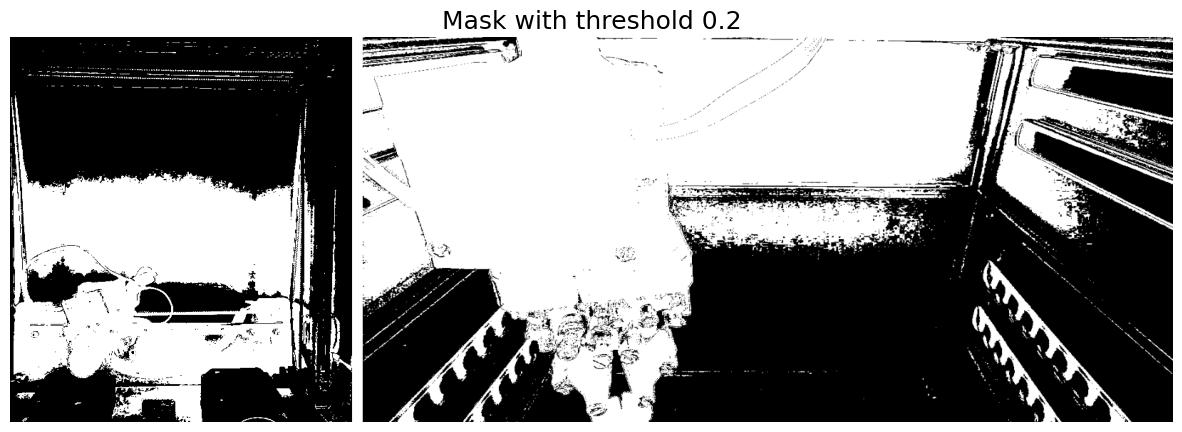

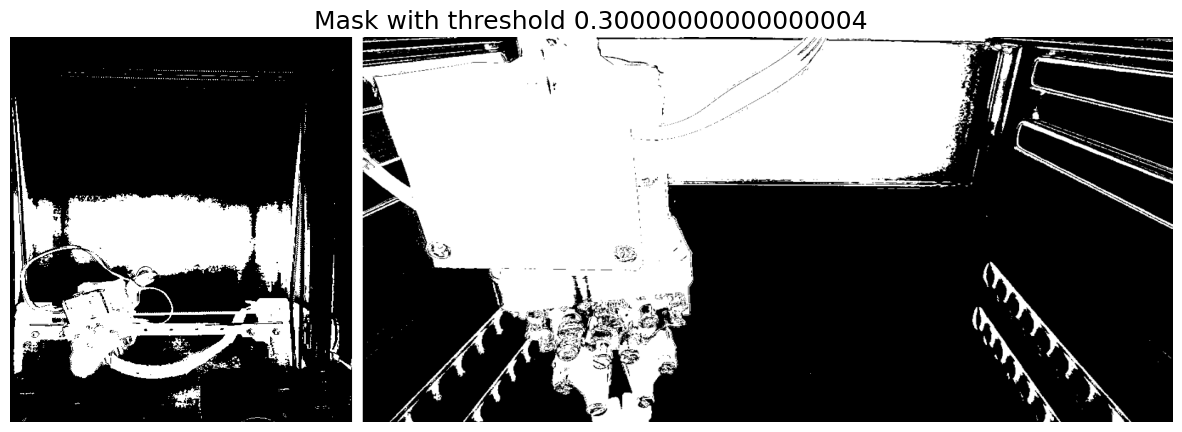

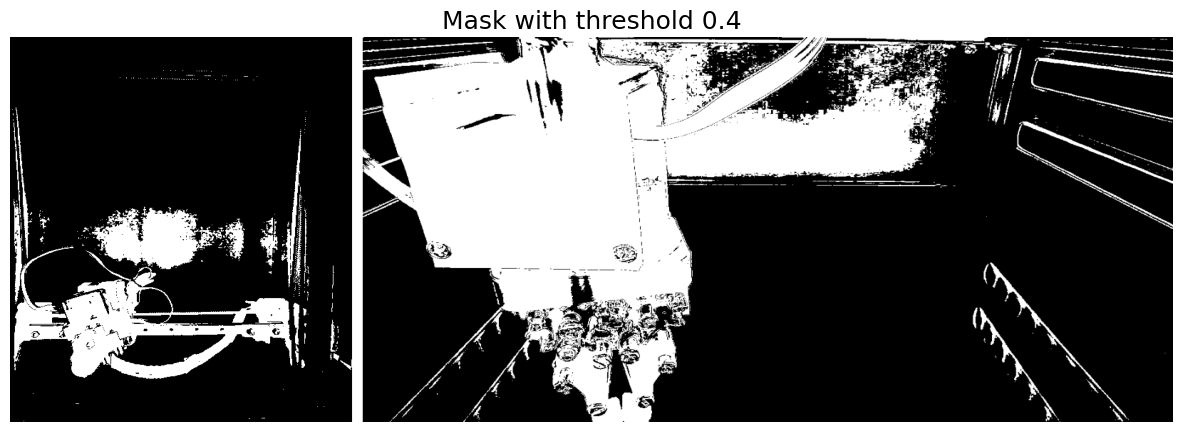

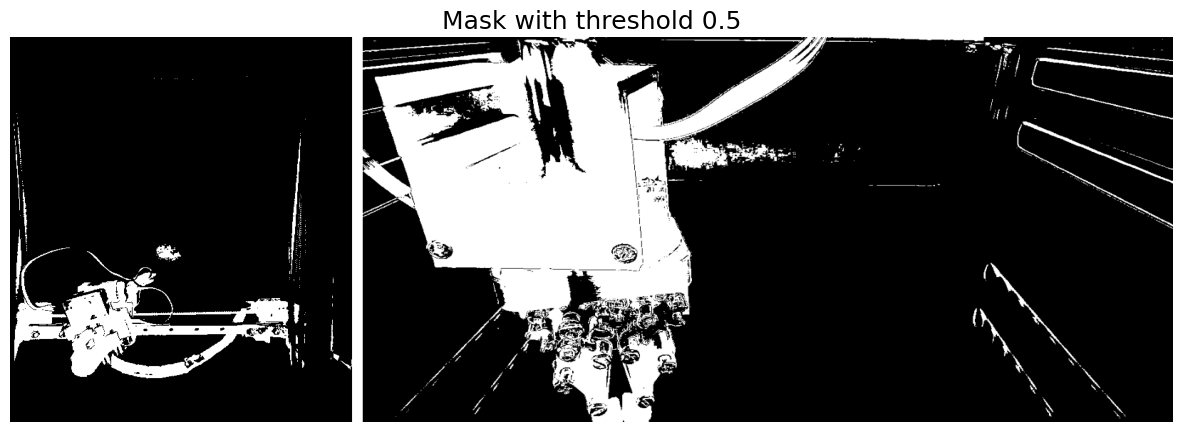

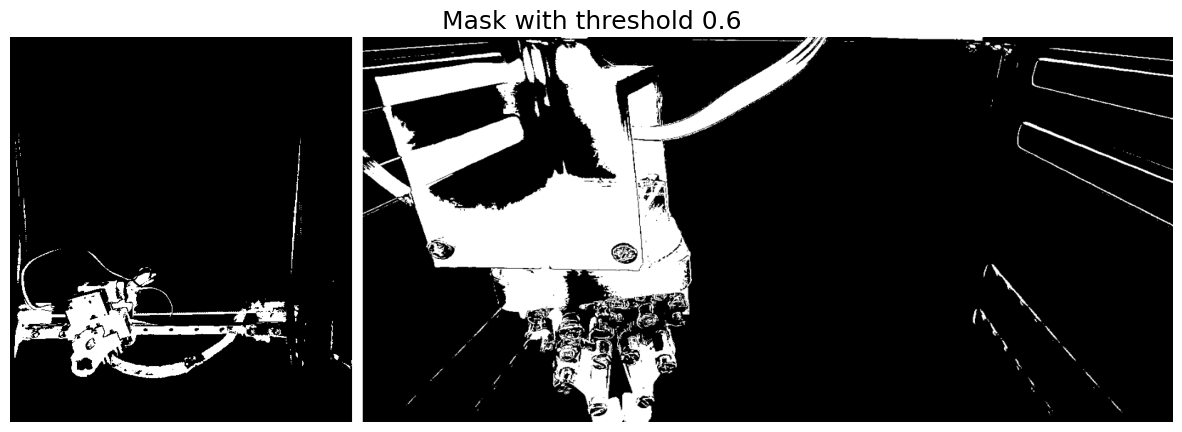

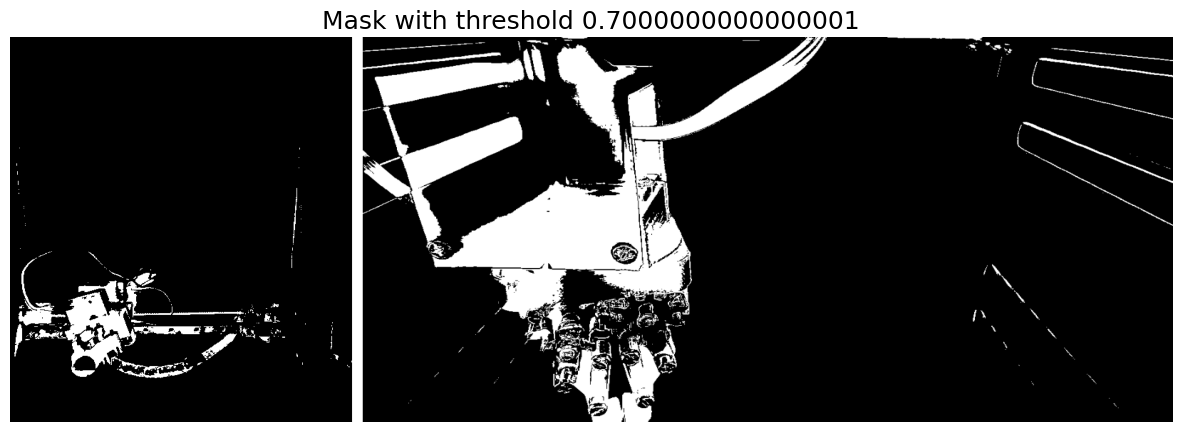

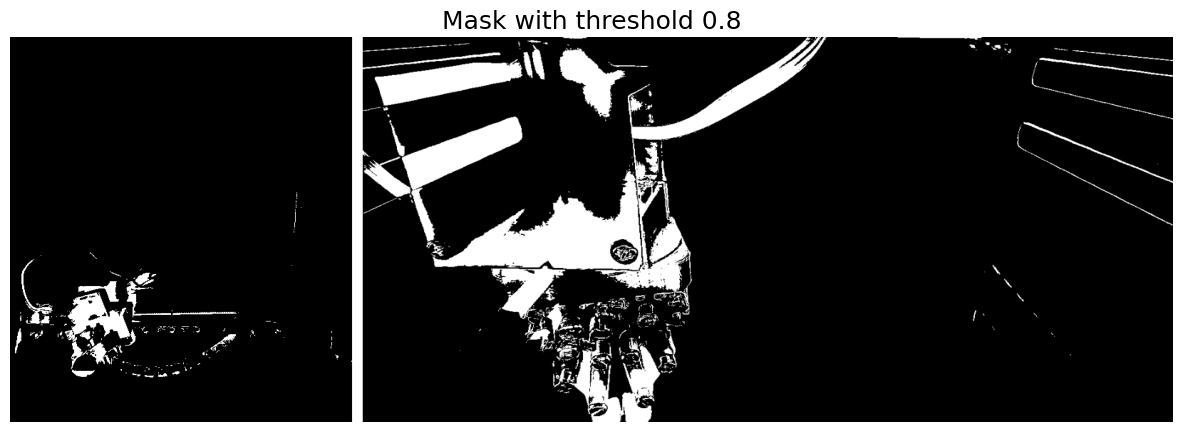

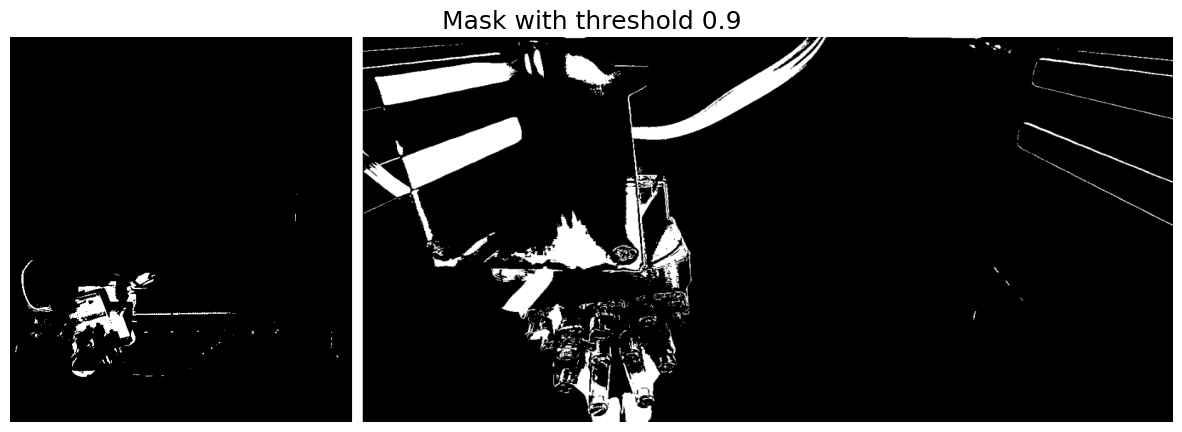

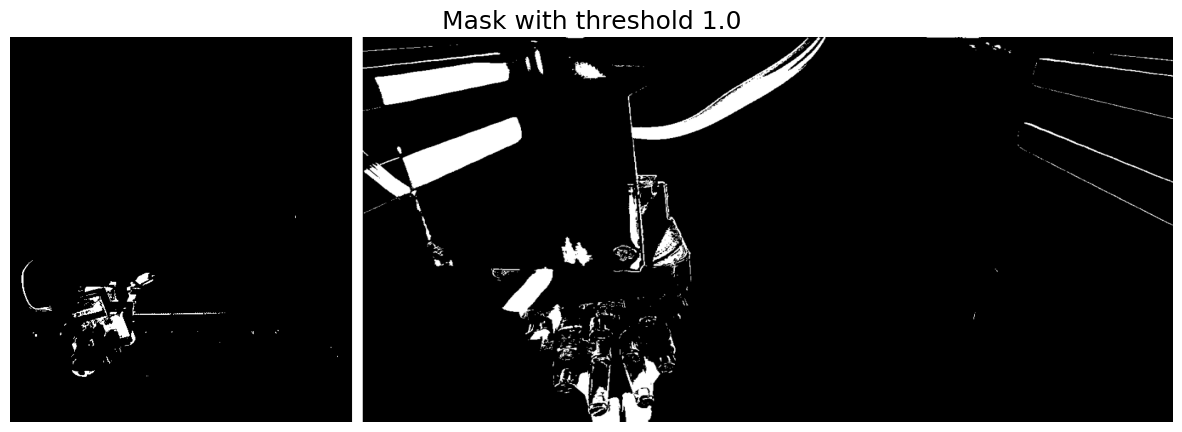

In [ ]:
# threshold the sum of the 3 RGB values
thresholds = np.linspace(0.1,1,10)

for i in range(1):
    bottom_img, top_img, state = dataset[i]
    bottom_img = bottom_img.numpy()
    top_img = top_img.numpy()
    plot_images(bottom_img, top_img, title="Initial image")

    mask_bottom = np.abs(mean_bottom - bottom_img)
    mask_top = np.abs(mean_top - top_img)
    # mask_bottom = np.sqrt((mean_bottom - bottom_img)**2)
    # mask_top = np.sqrt((mean_top - top_img)**2)
    plot_images(mask_bottom, mask_top, title="Environment subtraction")

    # sum RGB values
    rgb_bottom = mask_bottom.sum(axis=2)[:,:,np.newaxis]
    rgb_top = mask_top.sum(axis=2)[:,:,np.newaxis]

    for threshold in thresholds:
        mask_bottom = np.where(np.repeat(rgb_bottom,3,axis=2)<threshold, 0, 1).astype(np.float32)
        mask_top = np.where(np.repeat(rgb_top,3,axis=2)<threshold, 0, 1).astype(np.float32)
        plot_images(mask_bottom, mask_top, title=f"Mask with threshold {threshold}")
